In [ ]:
############################################################################################################################################################
# FAST WORKFLOW
############################################################################################################################################################
from sklearn.metrics import classification_report
from tmp_software.graphs import VisualiseGraph
from tmp_software.tools import ConfusionMatrix
from tmp_software import FastTMP
import pandas as pd
import json
import matplotlib.pyplot as plt

# State rows to keep
keep=['accession', 'thermal_range', 'thermal_source', 'thermal_reasoning', 'thermal_confidence', 'thermal_source', 'inference_type', 'thermal_paper', 'host','taxonomic_level','host_reasoning','host_confidence','host_source','host_paper','duration', 'nodes', 'timings']

#Getting accessions
ex_df=pd.read_csv('../example_data/expanded_example_data.csv')
accessions=ex_df['Accession']


all_df = pd.DataFrame()

# Classifying each accession
preds=[]
for acc in accessions:
    print(f'Accession: {acc}')
    result = FastTMP(acc, "gemma4:e4b")


    preds.append(result.get('thermal_range', None))
    print(f'\n{acc}: {result.get("thermal_range", None)}')
    df = pd.DataFrame([result])

    # serialize complex fields
    df["metadata"] = df["metadata"].apply(json.dumps)
    df["timings"] = df["timings"].apply(json.dumps)
    df["nodes"] = df["nodes"].apply(json.dumps)

    all_df = pd.concat([all_df, df], ignore_index=True)



all_df["thermal_range"] = preds

all_df.to_csv('fast/fast_result.csv', index=False)

# Create confusion matrix
actual=ex_df['Thermal Range']
pred=all_df['thermal_range']

#Clean out None
actual_clean = actual.fillna("unknown")
pred_clean = pred.fillna("unknown")

plot=ConfusionMatrix(actual_clean, pred_clean)
plot.plot(cmap='Blues')
plt.savefig('fast/fast_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


# Total duration
import pandas as pd
df=pd.read_csv('fast/fast_result.csv')
total_duration=0
for i in df['duration']:
    total_duration+=i
print(f'Total Duration: {round((total_duration/60),2)} minutes')

# Get the classification report
classification_report=classification_report(actual_clean, pred_clean)

with open('fast/fast_classification_report.txt', 'w') as f:
    f.write(classification_report)
    f.write(f'\n\n Total Duration: {round((total_duration/60),2)} minutes')


In [ ]:
############################################################################################################################################################
# Democratic WORKFLOW
############################################################################################################################################################
from sklearn.metrics import classification_report
from tmp_software.tools import ConfusionMatrix
from tmp_software import DemocraticTMP
import pandas as pd
import json
import matplotlib.pyplot as plt

# State rows to keep
keep=['accession', 'thermal_range', 'thermal_source', 'thermal_reasoning', 'thermal_confidence', 'thermal_source', 'inference_type', 'thermal_paper', 'host','taxonomic_level','host_reasoning','host_confidence','host_source','host_paper','duration', 'nodes', 'timings']

#Getting accessions
ex_df=pd.read_csv('../example_data/expanded_example_data.csv')
accessions=ex_df['Accession']


all_df = pd.DataFrame()

# Classifying each accession
preds=[]
for acc in accessions:
    print(f'Accession: {acc}')
    result = DemocraticTMP(acc, "gemma4:e4b")


    preds.append(result.get('thermal_range', None))
    print(f'\n{acc}: {result.get("thermal_range", None)}')
    df = pd.DataFrame([result])

    # serialize complex fields
    df["metadata"] = df["metadata"].apply(json.dumps)
    df["timings"] = df["timings"].apply(json.dumps)
    df["nodes"] = df["nodes"].apply(json.dumps)

    all_df = pd.concat([all_df, df], ignore_index=True)



all_df["thermal_range"] = preds

all_df.to_csv('democratic/democratic_result.csv', index=False)

# Create confusion matrix
actual=ex_df['Thermal Range']
pred=all_df['thermal_range']

#Clean out None
actual_clean = actual.fillna("unknown")
pred_clean = pred.fillna("unknown")

plot=ConfusionMatrix(actual_clean, pred_clean)
plot.plot(cmap='Blues')
plt.savefig('democratic/democratic_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


# Total duration
import pandas as pd
df=pd.read_csv('democratic/democratic_result.csv')
total_duration=0
for i in df['duration']:
    total_duration+=i
print(f'Total Duration: {round((total_duration/60),2)} minutes')

# Get the classification report
classification_report=classification_report(actual_clean, pred_clean)

with open('democratic/democratic_classification_report.txt', 'w') as f:
    f.write(classification_report)
    f.write(f'\n\n Total Duration: {round((total_duration/60),2)} minutes')


In [ ]:
############################################################################################################################################################
# Summary WORKFLOW
############################################################################################################################################################
from sklearn.metrics import classification_report
from tmp_software.tools import ConfusionMatrix
from tmp_software import SummaryTMP
import pandas as pd
import json
import matplotlib.pyplot as plt

# State rows to keep
keep=['accession', 'thermal_range', 'thermal_source', 'thermal_reasoning', 'thermal_confidence', 'thermal_source', 'inference_type', 'thermal_paper', 'host','taxonomic_level','host_reasoning','host_confidence','host_source','host_paper','duration', 'nodes', 'timings']

#Getting accessions
ex_df=pd.read_csv('../example_data/expanded_example_data.csv')
accessions=ex_df['Accession']


all_df = pd.DataFrame()

# Classifying each accession
preds=[]
for acc in accessions:
    print(f'Accession: {acc}')
    result = SummaryTMP(acc, "gemma4:e4b")


    preds.append(result.get('thermal_range', None))
    print(f'\n{acc}: {result.get("thermal_range", None)}')
    df = pd.DataFrame([result])

    # serialize complex fields
    df["metadata"] = df["metadata"].apply(json.dumps)
    df["timings"] = df["timings"].apply(json.dumps)
    df["nodes"] = df["nodes"].apply(json.dumps)

    all_df = pd.concat([all_df, df], ignore_index=True)



all_df["thermal_range"] = preds

all_df.to_csv('summary/summary_result.csv', index=False)

# Create confusion matrix
actual=ex_df['Thermal Range']
pred=all_df['thermal_range']

#Clean out None
actual_clean = actual.fillna("unknown")
pred_clean = pred.fillna("unknown")

plot=ConfusionMatrix(actual_clean, pred_clean)
plot.plot(cmap='Blues')
plt.savefig('summary/summary_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


# Total duration
import pandas as pd
df=pd.read_csv('summary/summary_result.csv')
total_duration=0
for i in df['duration']:
    total_duration+=i
print(f'Total Duration: {round((total_duration/60),2)} minutes')

# Get the classification report
classification_report=classification_report(actual_clean, pred_clean)

with open('summary/summary_classification_report.txt', 'w') as f:
    f.write(classification_report)
    f.write(f'\n\n Total Duration: {round((total_duration/60),2)} minutes')


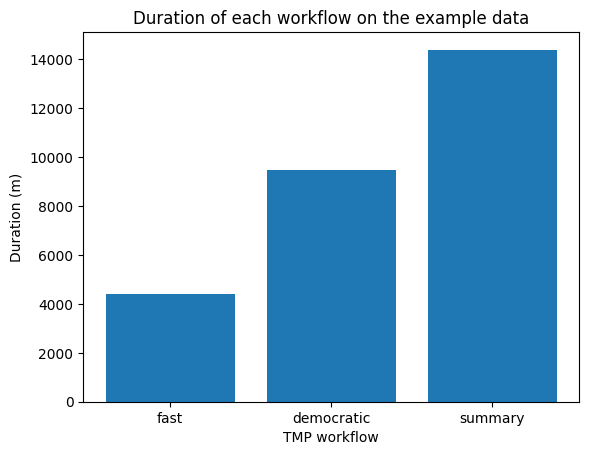

In [8]:
# Plot results
import matplotlib.pyplot as plt
import pandas as pd
fast=pd.read_csv('fast/fast_result.csv')
democratic=pd.read_csv('democratic/democratic_result.csv')
summary=pd.read_csv('summary/summary_result.csv')


fast_duration=fast['duration'].sum()
democratic_duration=democratic['duration'].sum()
summary_duration=summary['duration'].sum()

labels=['fast','democratic', 'summary']
values=[fast_duration,democratic_duration,summary_duration]


# Create bar chart
plt.bar(labels, values)

# Labels and title
plt.xlabel('TMP workflow')
plt.ylabel('Duration (m)')
plt.title('Duration of each workflow on the example data')

plt.show()